In [1]:
import pandas as pd
from modules.sentiment.rag.embedder import Embedder
from modules.sentiment.rag.vector_store import QdrantVectorStore
from modules.sentiment.rag.retriever import Retriever
from modules.sentiment.rag.generator import Generator
from modules.sentiment.evaluation.rag_metrics import faithfulness


c:\Users\sarfras\anaconda3\envs\crypto\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 670709db-2517-46a7-8921-0cb201ea437a)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


         id                                            content  source  length
0  25932728  US shutdown and weak jobs data drive record $6...    news     125
1   1nq01rx  Maybe the bull run already ended I've been inv...  reddit     705
2   1npzxig  Question - Crypto to Fiat withdrawal I am stil...  reddit     601
3   1npzkc1                          Altseason is coming bros   reddit      25
4   1npz0g7  Is wrapping BTC to cbBTC (or other wraps) when...  reddit    1373


<Axes: >

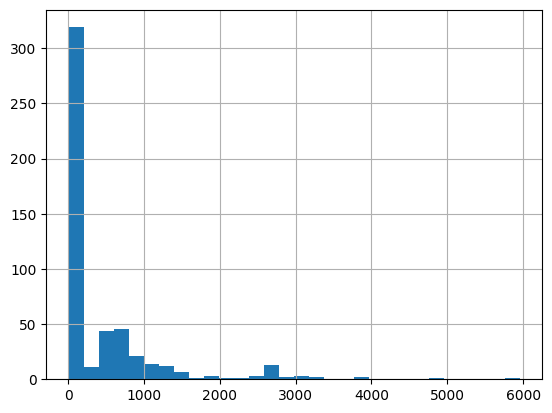

In [2]:
embedder = Embedder()
docs = embedder.fetch_docs()
df_docs = pd.DataFrame(docs)
df_docs['length'] = df_docs['content'].str.len()

print(df_docs.head())
df_docs['length'].hist(bins=30)

In [3]:
vector_store = QdrantVectorStore()
retriever = Retriever(embedder, vector_store)
query = "what is the current situation of ETH"
results = retriever.retrieve(query)

pd.DataFrame([{"score": r['score'], "content": r['content']} for r in results])

,score,content
0,1.000000,"* Every single dollar of stablecoins, RWAs (re..."
1,0.983871,ETH Snaps Back as Whales Load $480M and Cowen ...
2,0.960689,"The volatility is suppressed, and hence the pr..."
3,0.945793,* Major issuers led the Ethereum ETF withdrawa...
4,0.931352,"ETH price euphoria fades, but $5K remains the ..."


In [4]:
generator = Generator()
response = generator.generate(query, results) 

print("Query:", query)
print("\nResponse:", response)

Device set to use cpu
Both `max_new_tokens` (=300) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: what is the current situation of ETH

Response: The volatility is suppressed, and hence the price for bitcoin and eth (Wall Street is involved in mainly these two), leading to lackluster performance in other coins as well. There's absolutely no dou


In [5]:
contexts = [r['content'] for r in results]
faith = faithfulness(response, contexts)
print(f"Faithfulness: {faith:.4f}")

Faithfulness: 0.9655
